In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

In [4]:
df=pd.read_csv('/content/Sample_ Superstore3.csv')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Segment,0
Country,0
City,0
State,0


In [5]:
df.shape

(9994, 19)

In [6]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
print(df.isnull().sum())

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df['Order Date']=pd.to_datetime(df['Order Date'],format='mixed')
df['Ship Date']=pd.to_datetime(df['Ship Date'],format='mixed')

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Ship Date     9994 non-null   datetime64[ns]
 4   Ship Mode     9994 non-null   object        
 5   Customer ID   9994 non-null   object        
 6   Segment       9994 non-null   object        
 7   Country       9994 non-null   object        
 8   City          9994 non-null   object        
 9   State         9994 non-null   object        
 10  Region        9994 non-null   object        
 11  Product ID    9994 non-null   object        
 12  Category      9994 non-null   object        
 13  Sub-Category  9994 non-null   object        
 14  Product Name  9994 non-null   object        
 15  Sales         9994 non-null   float64 

In [11]:
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month

In [12]:
monthly_sales=df.groupby(['Year','Month'])[['Sales','Profit']].sum().reset_index()

In [13]:
print(monthly_sales.head(10))

   Year  Month       Sales     Profit
0  2014      1  14236.8950  2450.1907
1  2014      2   4519.8920   862.3084
2  2014      3  55691.0090   498.7299
3  2014      4  28295.3450  3488.8352
4  2014      5  23648.2870  2738.7096
5  2014      6  34595.1276  4976.5244
6  2014      7  33946.3930  -841.4826
7  2014      8  27909.4685  5318.1050
8  2014      9  81777.3508  8328.0994
9  2014     10  31453.3930  3448.2573


In [14]:
monthly_sales['Date']=pd.to_datetime(monthly_sales[['Year','Month']].assign(day=1))

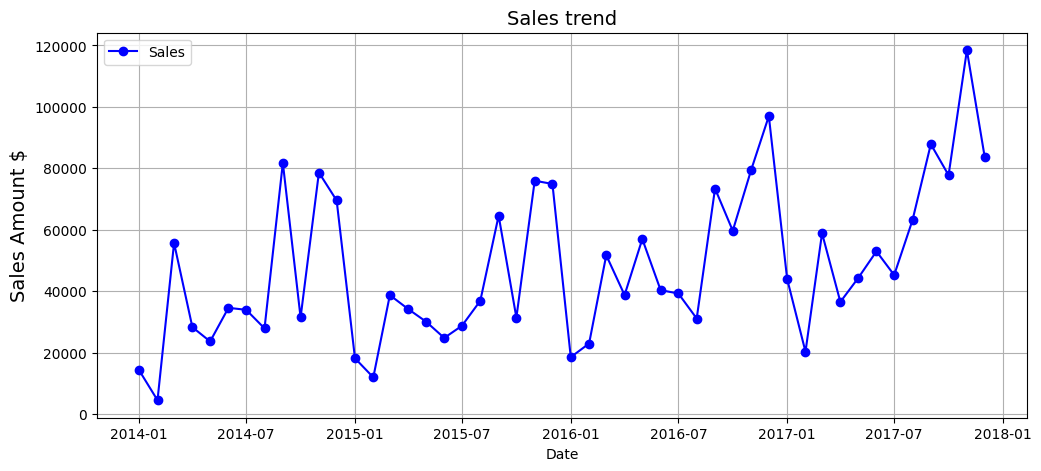

In [15]:
from ipywidgets.widgets.trait_types import Date
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'],monthly_sales['Sales'],marker='o',color='blue',label='Sales')
plt.title('Sales trend',fontsize=14)
plt.ylabel('Sales Amount $',fontsize=14)
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()


In [16]:
category_sales=df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

In [17]:
print(category_sales)

          Category        Sales
0       Technology  836154.0330
1        Furniture  741999.7953
2  Office Supplies  719047.0320


In [18]:
category_profit=df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()

In [19]:
print(category_profit)

          Category       Profit
0       Technology  145454.9481
1  Office Supplies  122490.8008
2        Furniture   18451.2728


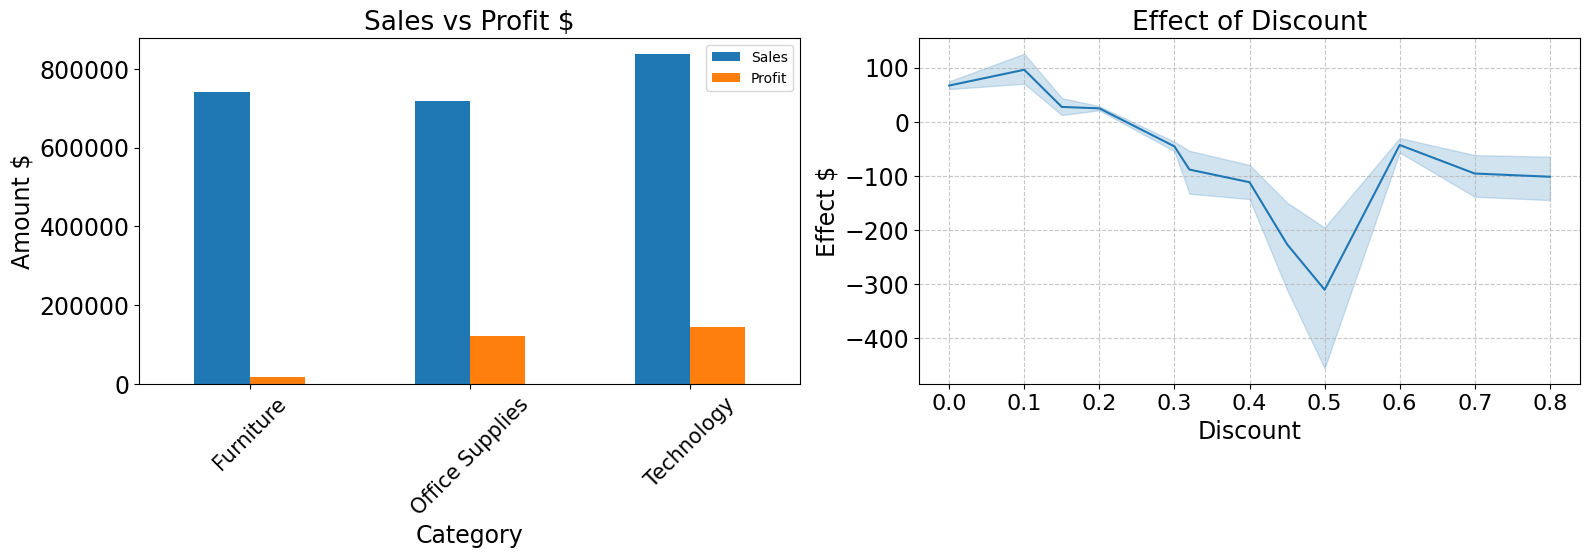

In [20]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
category_sales_profit=df.groupby('Category')[['Sales','Profit']].sum()
category_sales_profit.plot(kind='bar',ax=axes[0],color=['#1f77b4','#ff7f0e'])
axes[0].set_title('Sales vs Profit $',fontsize=19)
axes[0].set_ylabel('Amount $',fontsize=17)
axes[0].set_xlabel('Category',fontsize=17)
axes[0].tick_params(axis='y',labelsize=17)
axes[0].tick_params(axis='x',labelsize=15)
sns.lineplot(data=df,x='Discount',y='Profit',ax=axes[1])
axes[1].set_title('Effect of Discount',fontsize=19)
axes[1].set_ylabel('Effect $',fontsize=17)
axes[1].set_xlabel('Discount',fontsize=17)
axes[1].tick_params(axis='y',labelsize=17)
axes[1].tick_params(axis='x',labelsize=16)
axes[1].grid(True,linestyle='--',alpha=0.7)
plt.tight_layout()
axes[0].tick_params(axis='x',rotation=45)
plt.show()

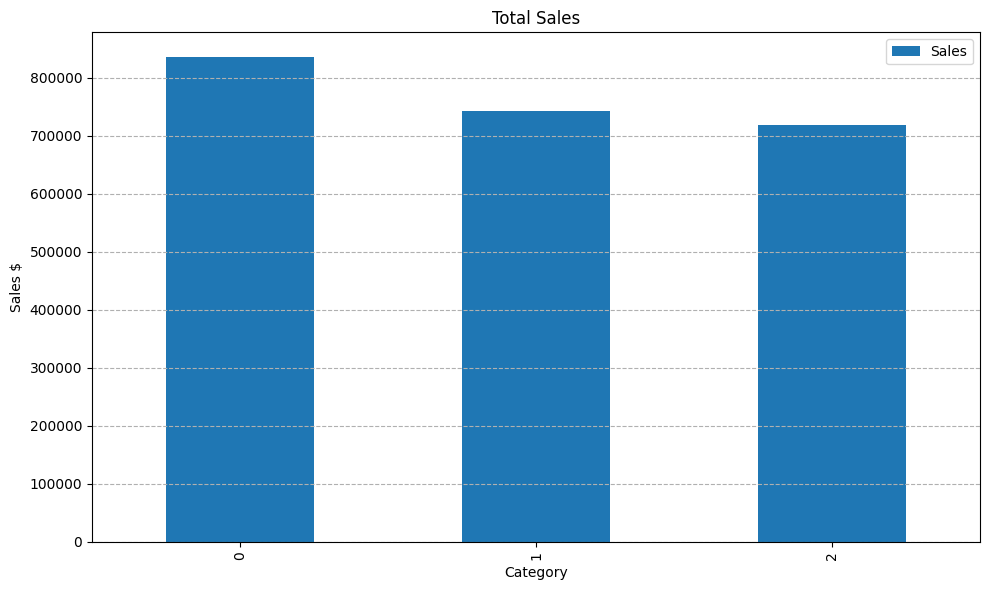

In [21]:
category_sales.plot(kind='bar',figsize=(10,6))
plt.title('Total Sales')
plt.xlabel('Category')
plt.ylabel('Sales $')
plt.grid(axis='y',linestyle='--')
plt.tight_layout()


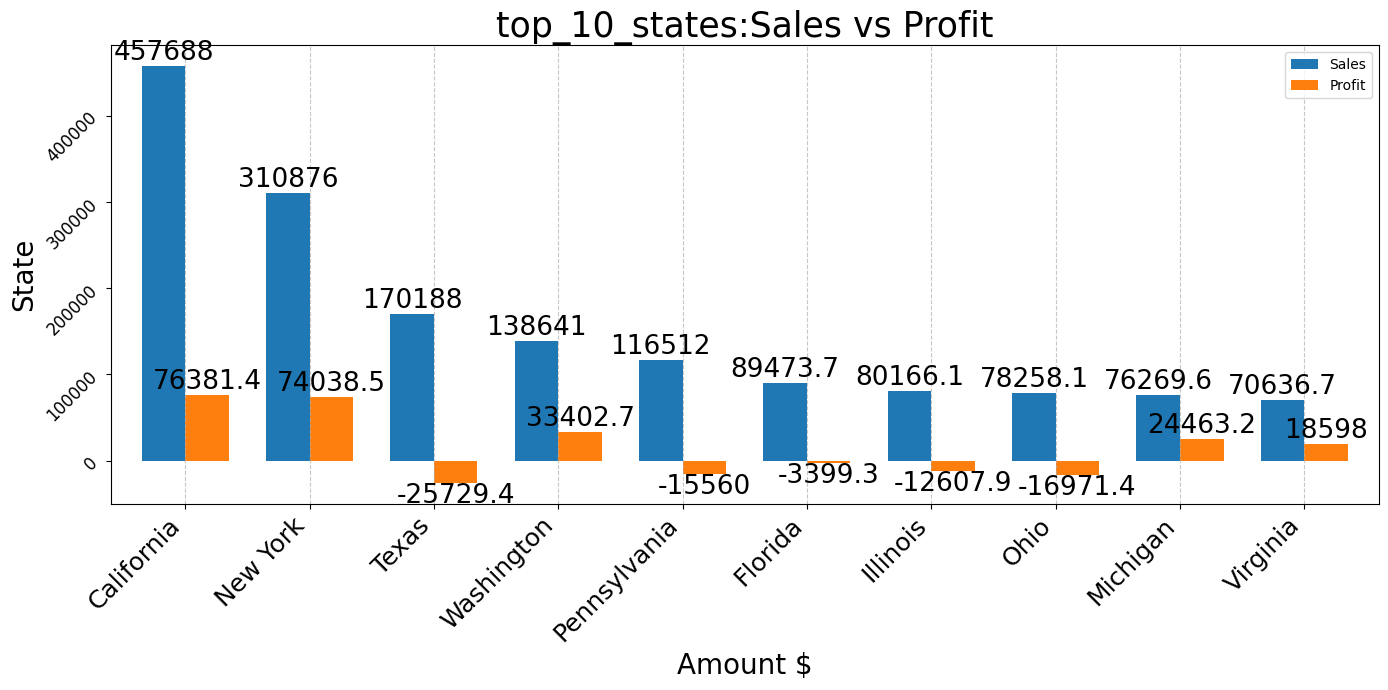

In [22]:
from pandas.core.accessor import PandasDelegate
state_data=df.groupby('State')[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False)
top_10_states=state_data.head(10)
fig,ax=plt.subplots(figsize=(14,7))
top_10_states.plot(kind='bar',ax=ax,width=0.7)
plt.xticks(rotation=45,ha='right')
ax.tick_params(axis='y',labelsize=25)
ax.tick_params(axis='x',labelsize=18)
for container in ax.containers:
  labels=[f'{v.get_width():.0f}'for v in container]
  ax.bar_label(container,fontsize=19)
plt.title('top_10_states:Sales vs Profit',fontsize=25)
plt.yticks(rotation=45,ha='right',fontsize=12)
plt.ylabel('State',fontsize=20)
plt.xlabel('Amount $',fontsize=20)
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.subplots_adjust(left=0.2)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Sales Distribution by ategory')

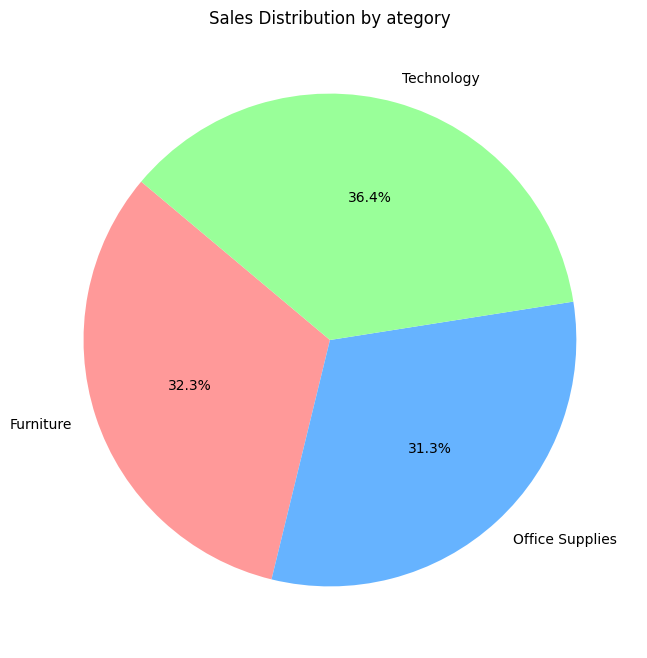

In [23]:
category_sales=df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,8))
plt.pie(category_sales,labels=category_sales.index,autopct='%1.1f%%',startangle=140,colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Sales Distribution by ategory')

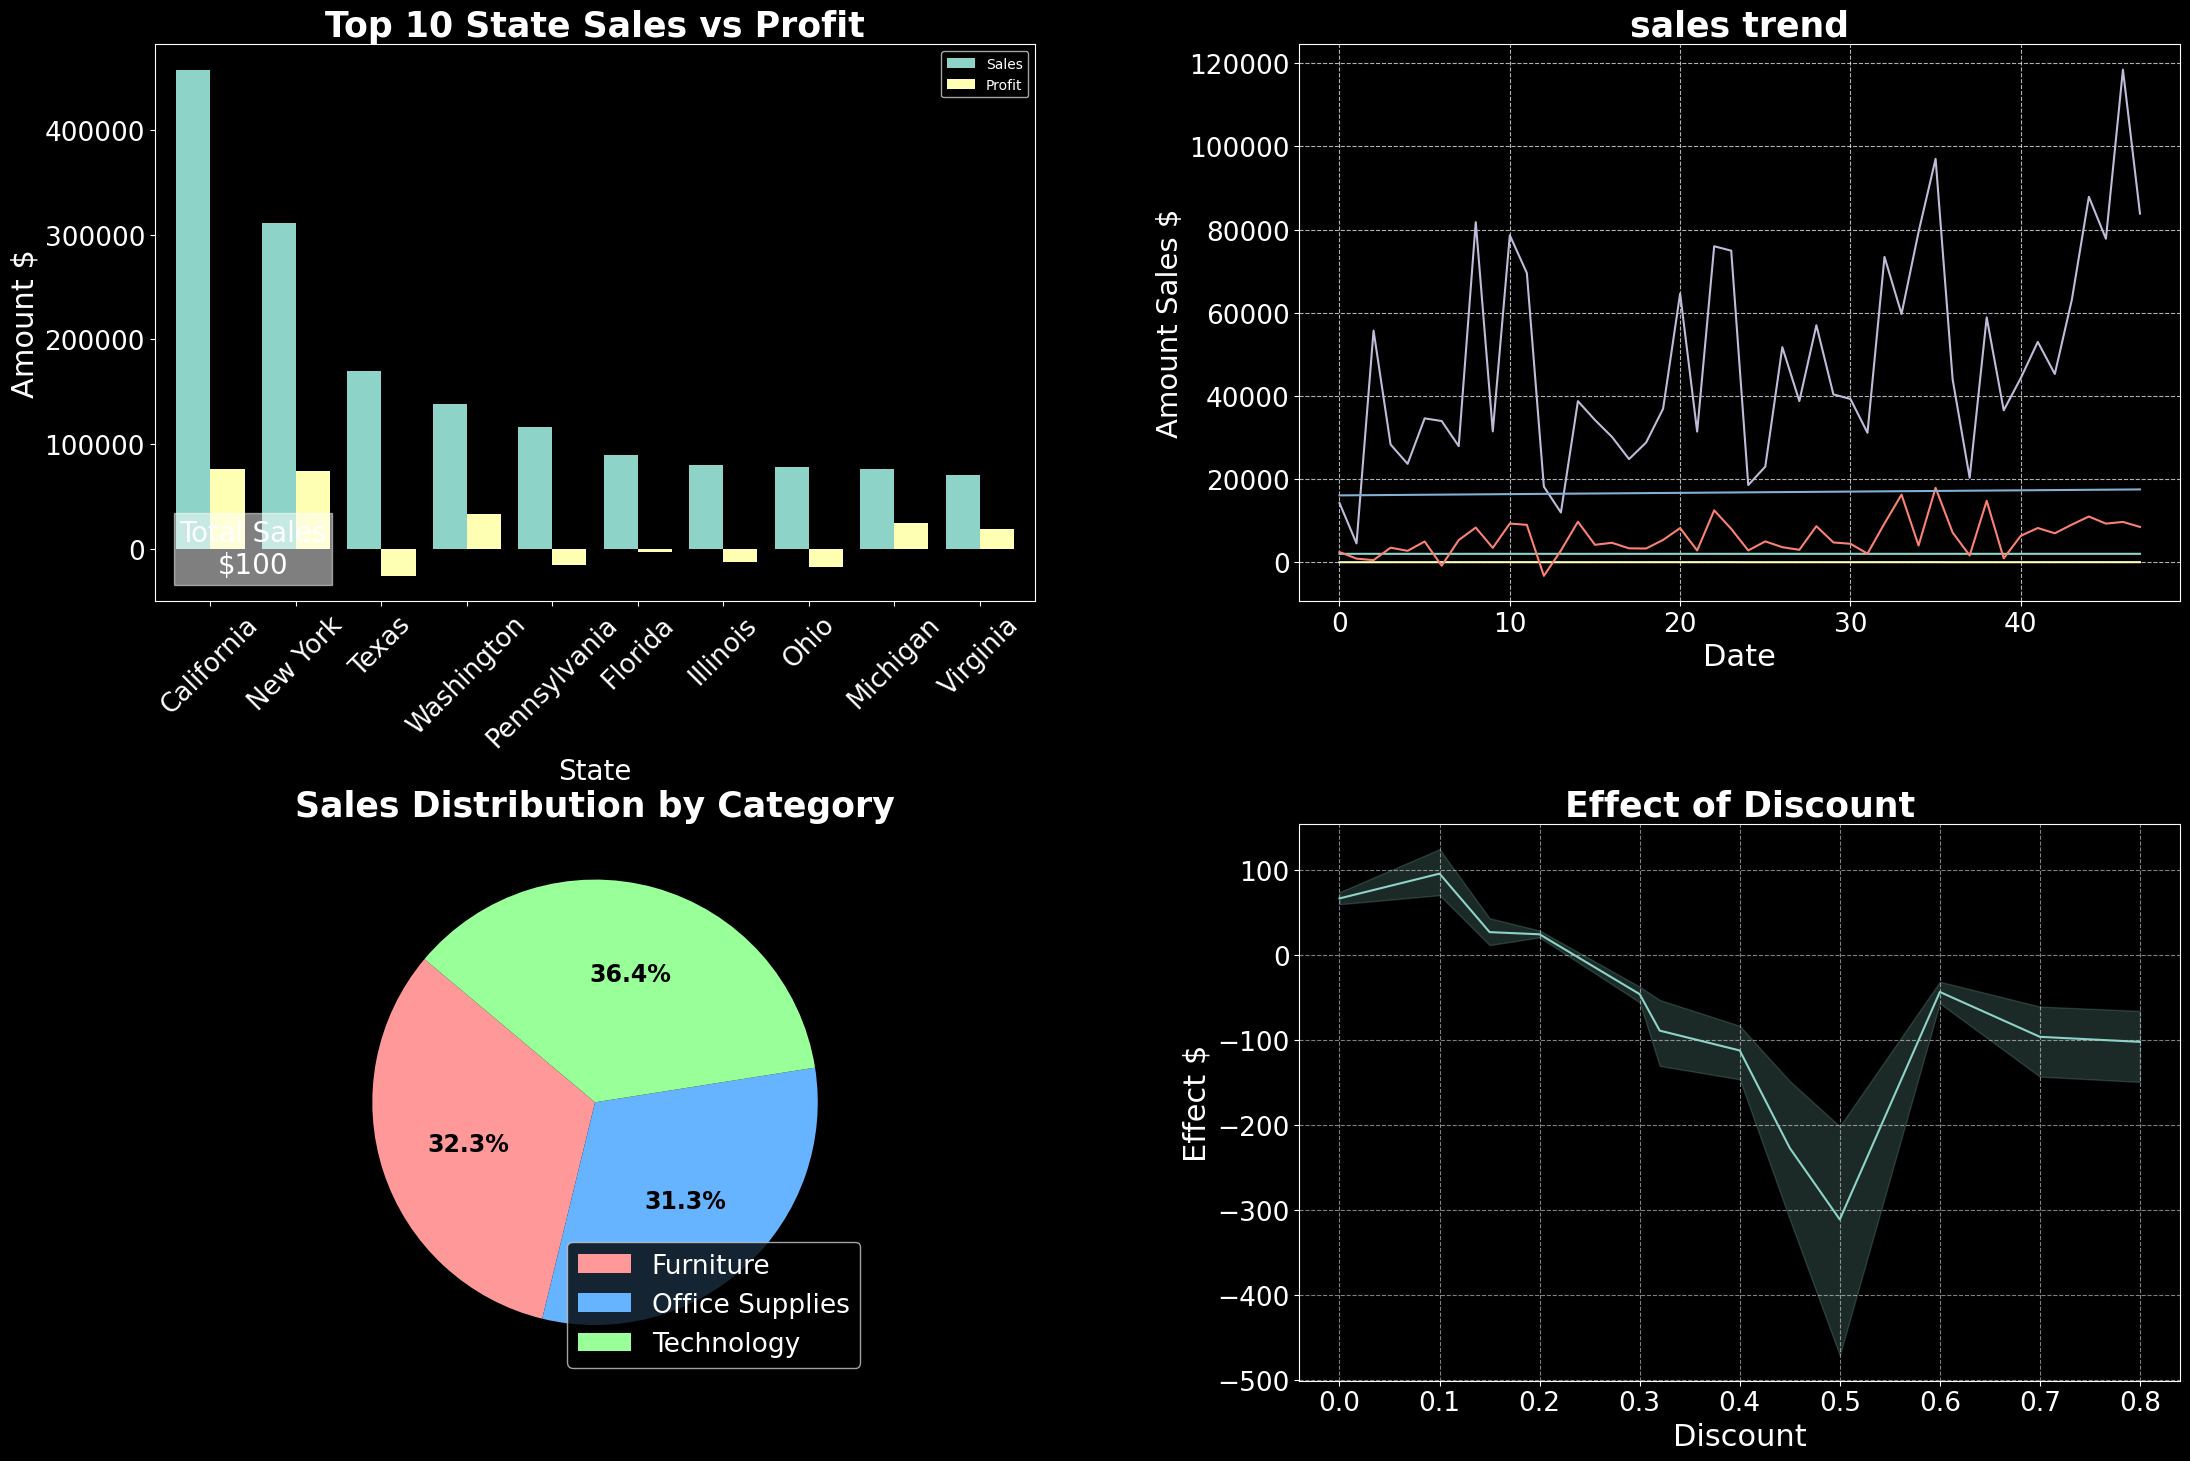

In [73]:
fig,axes=plt.subplots(2,2,figsize=(22,16))
dropdown=widgets.Dropdown(options=df['State'].unique(),description='State:')
def show_data(state_name):
  filterd_df=df[df['State']==state_name]
  print(state_name)
  widgets.interact(show_data,state_name=dropdown)
  def update_dashboard(selected_state):
    df_new=df[df['State']==selected_state]
colors=['#ff9999','#66b3ff','#99ff99']
sns.set_palette('viridis')
plt.style.use('dark_background')
top_10_states.plot(kind='bar',  ax=axes[0,0],width=0.8)
axes[0,0].text(0.5,0.5,'Total Sales\n$100',ha='center',va='center',fontsize=20,bbox=dict(facecolor='white',alpha=0.5))
axes[0,0].set_title('Top 10 State Sales vs Profit',fontsize=25,fontweight='bold')
axes[0,0].tick_params(axis='x',labelsize=19,rotation=45)
axes[0,0].tick_params(axis='y',labelsize=19)
axes[0,0].set_ylabel('Amount $',fontsize=22)
axes[0,0].set_xlabel('State',fontsize=20)
axes[0,1].plot(monthly_sales)
axes[0,1].set_title('sales trend',fontsize=25,fontweight='bold');
axes[0,1].tick_params(axis='x',labelsize=19)
axes[0,1].tick_params(axis='y',labelsize=19)
axes[0,1].set_xlabel('Date',fontsize=22)
axes[0,1].set_ylabel('Amount Sales $',fontsize=21)
axes[0,1].grid(True,linestyle='--',alpha=0.7)
wedges,texts,autotexts=axes[1,0].pie(category_sales,labels=None,autopct='%1.1f%%',startangle=140,colors=colors,textprops={'fontsize':18,'color':'white'})
axes[1,0].legend(labels=category_sales.index,loc='best',fontsize=19)
for text in texts:
  text.set_fontsize(19)
  text.set_color('white')
  text.set_weight('bold')
  for autotext in autotexts:
    autotext.set_fontsize(17)
    autotext.set_weight('bold')
    autotext.set_color('black')
axes[1,0].set_title('Sales Distribution by Category',fontsize=25,fontweight='bold')
axes[1,0].tick_params(axis='y',labelsize=19)
axes[1,0].tick_params(axis='x',labelsize=19)
sns.lineplot(data=df,x='Discount',y='Profit',ax=axes[1,1])
axes[1,1].set_title('Effect of Discount',fontsize=25,fontweight='bold')
axes[1,1].tick_params('y',labelsize=19)
axes[1,1].tick_params('x',labelsize=19)
axes[1,1].set_ylabel('Effect $',fontsize=22)
axes[1,1].set_xlabel('Discount',fontsize=22)
axes[1,1].grid(True,linestyle='--',alpha=0.5)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.subplots_adjust(hspace=0.4,wspace=0.3)
plt.show()

